# 00 — Setup & EDA (RVL-CDIP)

In [1]:
%matplotlib inline
import sys, json
sys.path.insert(0, '..')
import pandas as pd
from IPython.display import Image, display, Markdown
from src import config as C, data
pd.set_option('display.max_colwidth', 40)
LABELS = data.get_label_names()
print('classes:', LABELS)

classes: ['letter', 'form', 'email', 'handwritten', 'advertisement', 'scientific report', 'scientific publication', 'specification', 'file folder', 'news article', 'budget', 'invoice', 'presentation', 'questionnaire', 'resume', 'memo']


In [2]:
import csv
from collections import Counter
def counts(csvp):
    return Counter(int(r['label']) for r in csv.DictReader(open(csvp)))
rows=[]
for split,csvp in [('train',C.MANIFEST_DIR/'train.csv'),('val',C.MANIFEST_DIR/'val.csv'),('test',C.MANIFEST_DIR/'test.csv')]:
    c=counts(csvp); rows.append({'split':split,'total':sum(c.values()),'min/classe':min(c.values()),'max/classe':max(c.values())})
pd.DataFrame(rows)

,split,total,min/classe,max/classe
0,train,32000,2000,2000
1,val,8000,500,500
2,test,16000,1000,1000


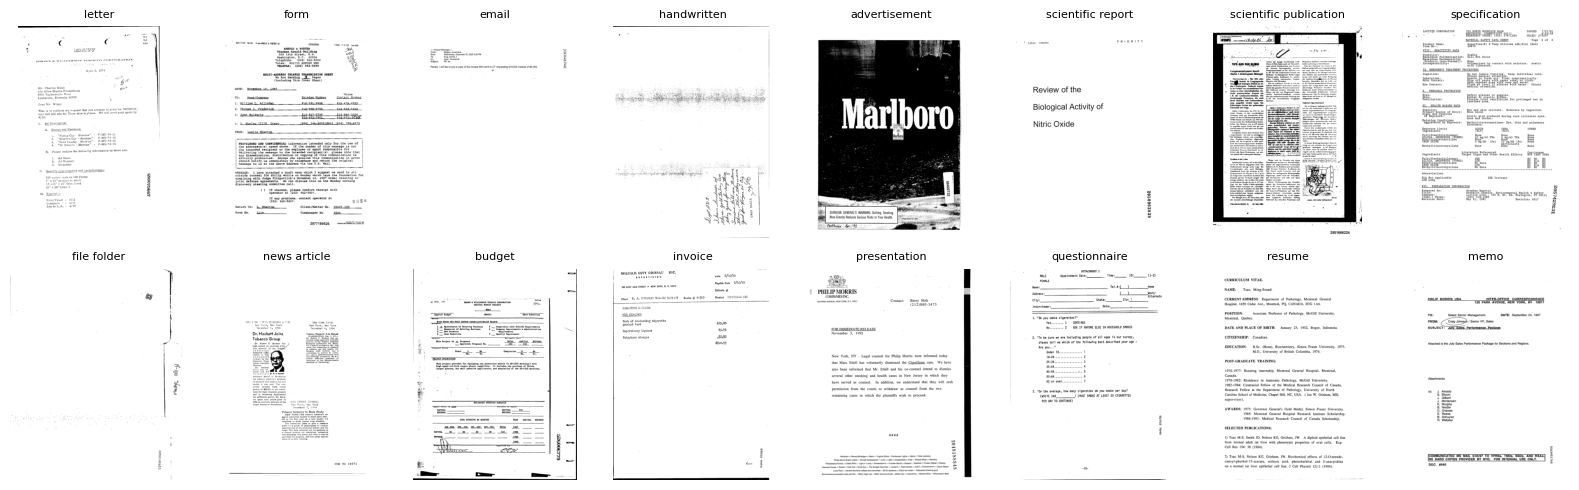

In [3]:
import matplotlib.pyplot as plt
from PIL import Image as PImage
import glob
fig,axes=plt.subplots(2,8,figsize=(16,5))
for i,ax in enumerate(axes.flat):
    fp=sorted(glob.glob(str(C.SUBSET_DIR/'test'/f'{i:02d}'/'*.png')))[0]
    ax.imshow(PImage.open(fp),cmap='gray'); ax.set_title(LABELS[i],fontsize=8); ax.axis('off')
plt.tight_layout(); display(fig)